In [1]:
import csv
import pandas as pd
from os import path
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import interpolate
import numpy.typing as npt
from numpy.random import choice
import random


In [2]:
pd.set_option('display.max_rows', 15)  # The number of rows above which it'll truncate the dataframe when displaying it. 
pd.set_option('display.min_rows', 10)  # The number of rows it'll be truncated to. 

### Reading in the demography for each area

In [3]:
df_male = pd.read_csv('../Demography by Area/outputs/demography_male.csv', index_col='geo_unit')
df_female = pd.read_csv('../Demography by Area/outputs/demography_female.csv', index_col='geo_unit')

df_male

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
geo_unit,,,,,,,,,,,,,,,,,,,,,
TEMP000001,3,5,2,7,5,3,2,3,3,3,...,0,0,0,0,0,0,0,0,0,0
TEMP000002,2,1,2,1,1,4,5,2,2,2,...,0,0,0,0,0,0,0,0,0,0
TEMP000003,4,4,1,4,2,1,4,4,3,3,...,0,0,0,0,0,0,0,0,0,0
TEMP000004,3,2,3,5,4,1,5,3,2,4,...,0,0,0,0,0,0,0,0,0,0
TEMP000005,2,4,2,2,4,1,1,5,4,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TEMP019706,0,9,4,3,5,7,5,4,3,3,...,0,0,0,0,0,0,0,0,0,0
TEMP019707,3,1,5,4,4,4,1,4,2,2,...,0,0,0,0,0,0,0,0,0,0
TEMP019708,4,4,1,5,1,0,3,2,1,4,...,0,0,0,0,0,0,0,0,0,0


## Building the Household function
Household types:

  - Solo Adult:  >18
  - Pair adult: two folk >18
  - Two adults with unknown number of kids.
  - Two plus adults with unknown number of kids. 

In [4]:
df_socioeconomic_dist = pd.read_csv('Social_Distribution_and_Households.txt', delimiter='\t', thousands=',')
df_socioeconomic_dist = df_socioeconomic_dist[df_socioeconomic_dist['Socio-economic group']!='Total']
df_socioeconomic_dist

,Socio-economic group,Number of households,Assumed mean household size,Total population
0,"Minor clergy, lawyers, professionals, merchant...",130000,5.5,715000
1,"Landowners (spiritual lords, aristocracy, gent...",21000,8.5,178500
2,Substantial tenants,12500,7.0,87500
3,Yardlanders,180000,5.5,990000
4,Smallholders,300000,4.0,1200000
5,Cottagers and agricultural labourers,240000,3.5,840000
6,"Rural craftsmen, non-agricultural labourers, p...",160000,3.5,560000
7,"Miners, men-at-arms, sailors, fishermen",50000,3.5,175000


In [5]:
df_socioeconomic_dist['Base Probability']=df_socioeconomic_dist['Number of households']/df_socioeconomic_dist['Number of households'].sum()
df_socioeconomic_dist

,Socio-economic group,Number of households,Assumed mean household size,Total population,Base Probability
0,"Minor clergy, lawyers, professionals, merchant...",130000,5.5,715000,0.118884
1,"Landowners (spiritual lords, aristocracy, gent...",21000,8.5,178500,0.019204
2,Substantial tenants,12500,7.0,87500,0.011431
3,Yardlanders,180000,5.5,990000,0.164609
4,Smallholders,300000,4.0,1200000,0.274348
5,Cottagers and agricultural labourers,240000,3.5,840000,0.219479
6,"Rural craftsmen, non-agricultural labourers, p...",160000,3.5,560000,0.146319
7,"Miners, men-at-arms, sailors, fishermen",50000,3.5,175000,0.045725


In [6]:
household_subtypes = [
    'Adult house',
    'Adults with Children',
]
household_subtype_distribution = np.array([
    1.,
    1.,
])
household_subtype_distribution /= household_subtype_distribution.sum()

# household_type_average_fill_adults = np.array([
#     2,
#     5,
#     1,
#     2,
#     4,
# ])
household_type_max_fill_adults= np.array([
    10,
    10,
])
household_type_max_fill_kids = np.array([
    0,
    15,
])

In [7]:
def choose_household(groups, probs, ave_occupation):
    # Choose what the socioeconomic group is first
    se_index = np.random.choice([i for i in range(len(groups))],p=probs)
    se_group = groups[se_index]
    # Returns the average occupation for that se_group
    average_occupation = ave_occupation[se_index]
    # Num occupants
    actual_occupation = max(1,round(np.random.poisson(lam=average_occupation)))
    num_kids = min(actual_occupation-1,round(np.random.poisson(lam=actual_occupation-2)))
    return se_group, se_index,  actual_occupation-num_kids, num_kids        

In [8]:
def create_household_numbers(
    num_adults, 
    num_kids, 
    groups=household_subtypes, 
    probs=household_subtype_distribution,
    ave_occupation=np.array([3,6])):
    # First approximation, generate random households until filled the people capacity. 
    household_counts = np.zeros(len(household_types), dtype=int)
    _total_adults = 0
    _total_kids = 0
    _indices = len(household_types)
    while _total_kids < num_kids or _total_adults < num_adults:
        se_group, se_index, nadults, nkids = choose_household(
            groups,
            probs,
            ave_occupation,
        )
        household_counts[se_index] += 1
        _total_adults += nadults
        _total_kids += nkids
    return household_counts

In [9]:
def create_household_numbers(
    num_adults, 
    num_kids, 
    groups=df_socioeconomic_dist['Socio-economic group'], 
    probs=df_socioeconomic_dist['Base Probability'],
    ave_occupation=df_socioeconomic_dist['Assumed mean household size']
):
    # First approximation, generate random households until filled the people capacity. 
    household_counts = np.zeros(len(household_types), dtype=int)
    _total_adults = 0
    _total_kids = 0
    _indices = len(household_types)
    while _total_kids < num_kids or _total_adults < num_adults:
        se_group, se_index, nadults, nkids = choose_household(
            groups,
            probs,
            ave_occupation,
        )
        household_counts[se_index] += 1
        _total_adults += nadults
        _total_kids += nkids
    return household_counts

In [10]:
kids = df_male.loc[:,[str(i) for i in range(18)]].sum(axis=1) + df_female.loc[:,[str(i) for i in range(18)]].sum(axis=1)
adults = df_male.loc[:,[str(i) for i in range(18,100)]].sum(axis=1) + df_female.loc[:,[str(i) for i in range(18,100)]].sum(axis=1)

In [11]:
household_composition = pd.DataFrame(data={'kids':kids, 'adults':adults})
household_composition

,kids,adults
geo_unit,,
TEMP000001,101,95
TEMP000002,91,106
TEMP000003,106,91
TEMP000004,99,98
TEMP000005,98,99
...,...,...
TEMP019706,127,133
TEMP019707,101,104
TEMP019708,83,87


In [12]:
#household_composition.to_csv('household_comp_1348_simple.csv')

In [13]:
household_composition['Adults with children'] = np.round(household_composition['kids'] / 5)
household_composition['Adults only'] = np.round((household_composition['adults'] - 2*household_composition['Adults with children']) / 3)

household_composition.drop(columns=['kids','adults']).astype(int)

,Adults with children,Adults only
geo_unit,,
TEMP000001,20,18
TEMP000002,18,23
TEMP000003,21,16
TEMP000004,20,19
TEMP000005,20,20
...,...,...
TEMP019706,25,28
TEMP019707,20,21
TEMP019708,17,18


In [18]:
s = (household_composition['kids'] + household_composition['adults']) / (household_composition['Adults with children'] + household_composition['Adults only'])

<Axes: ylabel='Frequency'>

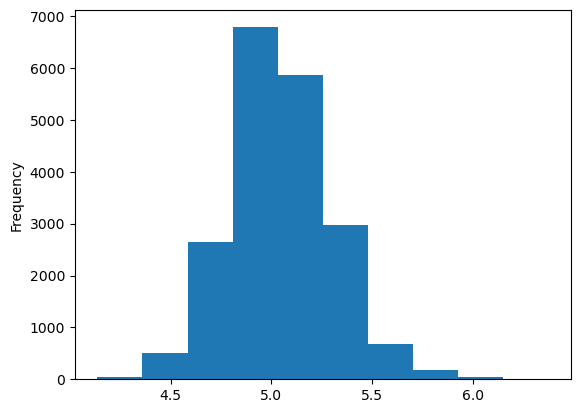

In [19]:
s.plot.hist()

In [15]:
#household_composition.drop(columns=['kids','adults']).astype(int).to_csv('household_comp_simple.csv')

In [33]:
#household_types = df_socioeconomic_dist['Socio-economic group']

#house_counts = np.zeros(shape=(len(household_composition), len(household_types)), dtype=int)
#household_composition[household_types] = house_counts
#household_composition

,kids,adults,"Minor clergy, lawyers, professionals, merchants, tradesmen, builders, craftsmen, urban labourers","Landowners (spiritual lords, aristocracy, gentry, clergy)",Substantial tenants,Yardlanders,Smallholders,Cottagers and agricultural labourers,"Rural craftsmen, non-agricultural labourers, paupers, vagrants","Miners, men-at-arms, sailors, fishermen"
geo_unit,,,,,,,,,,
TEMP000001,101,95,0,0,0,0,0,0,0,0
TEMP000002,91,106,0,0,0,0,0,0,0,0
TEMP000003,106,91,0,0,0,0,0,0,0,0
TEMP000004,99,98,0,0,0,0,0,0,0,0
TEMP000005,98,99,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TEMP019706,127,133,0,0,0,0,0,0,0,0
TEMP019707,101,104,0,0,0,0,0,0,0,0
TEMP019708,83,87,0,0,0,0,0,0,0,0


In [26]:
n=0
for i, row in household_composition.iterrows():
    household_composition.loc[i,household_types] += create_household_numbers(row['kids'],
                                                                       row['adults'])
    #household_composition.loc[i,household_types] += 
    n+=1
    print('Completed {:.0f} %'.format(n/N*100), end='\r')

ValueError: lam < 0 or lam is NaN

In [94]:
household_composition.drop(columns=['kids','adults'])

,Solo Adult,Adult Couple,Adult multi-house,Adult with children,Couple with Children,Adults with Children
geo_unit,,,,,,
TEMP000001,15,9,3,2,21,3
TEMP000002,20,18,3,12,9,5
TEMP000003,13,14,5,10,15,4
TEMP000004,12,6,7,10,15,3
TEMP000005,20,14,1,10,16,1
...,...,...,...,...,...,...
TEMP019706,19,17,5,8,21,5
TEMP019707,19,16,4,7,17,3
TEMP019708,12,15,2,5,14,3


In [99]:
# Average household population
total_pop = df_male.sum(axis=1) + df_female.sum(axis=1)
(total_pop / household_composition.drop(columns=['kids','adults']).sum(axis=1)).std()

np.float64(0.2596901870203132)

In [96]:
#household_composition.drop(columns=['kids','adults']).to_csv('household_composition_1348.csv')